<div align="center">

<img src="Logo_inpt.png" alt="INPT" width="160">


<br>
<h3 align="center">Institut National des Postes et Télécommunications (INPT)</h3>

<br><br>
<h1 align="center">Laaouafi Fatiha</h1>

</div>

In [17]:
## Start

# Interpolation (Lagrange , Newton , Hermite)

## Introduction

Interpolation consists of finding a polynomial P that passes exactly through a given set of points (xᵢ, yᵢ), where yᵢ = f(xᵢ). Once P is known, it can be used to estimate f at any other point.

In this notebook we study three methods:

- **Lagrange**: builds P directly from the basis polynomials Lᵢ(x).
- **Newton**: builds P with divided differences, which is easier to compute and to extend.
- **Hermite**: also uses the derivative f'(xᵢ) at each node, so P matches both the values and the slopes.

**Assignment**: select two functions, compute the interpolation polynomial with the three methods, compare the original function with the polynomial **while increasing the number of interpolation points**, and give feedback about the **Runge phenomenon**.

For each method we write the code, test it on the two chosen functions, plot the polynomial for an increasing number of nodes and visualise the error. At the end, we study the **Runge phenomenon**, which shows the limit of polynomial interpolation with equally spaced nodes.

### libraries

In [1]:
import sympy as sp 
import numpy as np
import matplotlib.pyplot as plt

### The two functions

- f₁(x) = 1 / (1 + 25x²) on [-1, 1] (the classical Runge function)
- f₂(x) = sin(x) on [-π, π] (a smooth function, for comparison)

`equi` gives equally spaced nodes and `cheb` gives Chebyshev nodes (used at the end).

In [2]:
f1  = lambda t: 1 / (1 + 25 * t**2)
df1 = lambda t: -50 * t / (1 + 25 * t**2)**2
f2  = np.sin
df2 = np.cos

# name : (f, f', a, b)
cases = {
    "f1(x) = 1/(1+25x²)": (f1, df1, -1.0, 1.0),
    "f2(x) = sin(x)":     (f2, df2, -np.pi, np.pi),
}

def equi(a, b, n):                      # n equally spaced nodes
    return np.linspace(a, b, n)

def cheb(a, b, n):                      # n Chebyshev nodes
    k = np.arange(n)
    return 0.5*(a + b) + 0.5*(b - a)*np.cos((2*k + 1)*np.pi/(2*n))

def clean(expr, d=4):                   # round the floats of a sympy expression (nicer display)
    return expr.xreplace({c: round(c, d) for c in expr.atoms(sp.Float)})

ns = [3, 5, 9, 13]                     

## Lagrange

In [3]:
def Lfct(x, X, k):
    L = 1
    factors = []
    for i in range(len(X)):
        if i != k:
            L *= (x - X[i]) / (X[k] - X[i])
            factors.append("((x-" + str(X[i]) + ")/(" + str(X[k]) + "-" + str(X[i]) + "))")
    return L, "*".join(factors)


def lagrange(x, X, Y):
    S = 0
    terms = []
    for i in range(len(X)):
        Li, expr = Lfct(x, X, i)  
        S += Y[i] * Li
        terms.append(str(Y[i]) + "*" + expr)
    return S, " + ".join(terms)

### Test

In [4]:
x = sp.symbols('x')
n = 5                                   
polyL = {}

for name, (f, df, a, b) in cases.items():
    X = list(equi(a, b, n))
    Y = [f(i) for i in X]

    t0 = (a + b) / 4                    # a point which is not a node
    val, ply = lagrange(t0, X, Y)
    print(name)
    print("   P(t0) =", val, "   f(t0) =", f(t0), "   error =", abs(val - f(t0)))

    _, ply = lagrange(x, X, Y)
    polyL[name] = sp.expand(sp.sympify(ply))
    print("   the polynome of lagrange is :", clean(polyL[name]))
    print()

polyL

f1(x) = 1/(1+25x²)
   P(t0) = 1.0    f(t0) = 1.0    error = 0.0
   the polynome of lagrange is : 3.3156*x**4 - 4.2772*x**2 + 1.0

f2(x) = sin(x)
   P(t0) = 0.0    f(t0) = 0.0    error = 0.0
   the polynome of lagrange is : -0.086*x**3 + 0.8488*x



{'f1(x) = 1/(1+25x²)': 3.3156498673740053*x**4 - 4.2771883289124669*x**2 + 1.0,
 'f2(x) = sin(x)': -0.086004091821865317*x**3 + 0.84882636315677516*x}

### Plot lagrange polynial

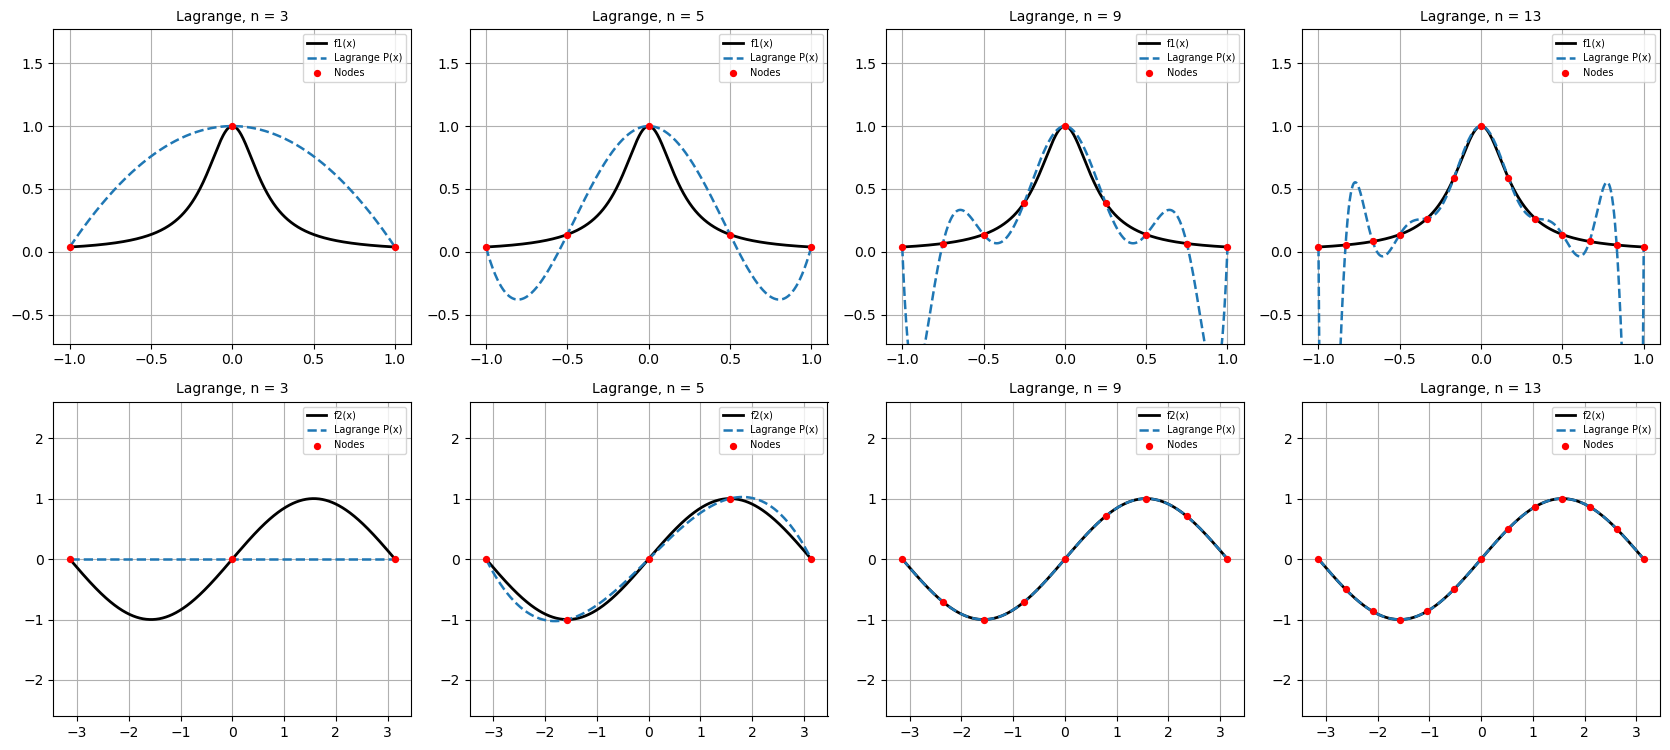

In [5]:
def plot_method(method, title, nodes=equi, ns=ns):
    
    fig, axes = plt.subplots(len(cases), len(ns), figsize=(4.2*len(ns), 3.8*len(cases)), squeeze=False)
    for r, (name, (f, df, a, b)) in enumerate(cases.items()):
        xs = np.linspace(a, b, 1000)
        lo, hi = f(xs).min(), f(xs).max()
        m = hi - lo
        for c, n in enumerate(ns):
            X = nodes(a, b, n)
            ax = axes[r, c]
            ax.plot(xs, f(xs), "k", lw=2, label=name.split(" =")[0])
            ax.plot(xs, method(xs, X, f, df), "--", lw=1.8, label=title + " P(x)")
            ax.scatter(X, f(X), color="red", zorder=5, s=18, label="Nodes")
            ax.set_ylim(lo - 0.8*m, hi + 0.8*m)
            ax.set_title(f"{title}, n = {n}", fontsize=10)
            ax.grid(True); ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def lagrange_eval(xs, X, f, df):
    return lagrange(xs, list(X), list(f(X)))[0]

plot_method(lagrange_eval, "Lagrange")

### Visualise the error

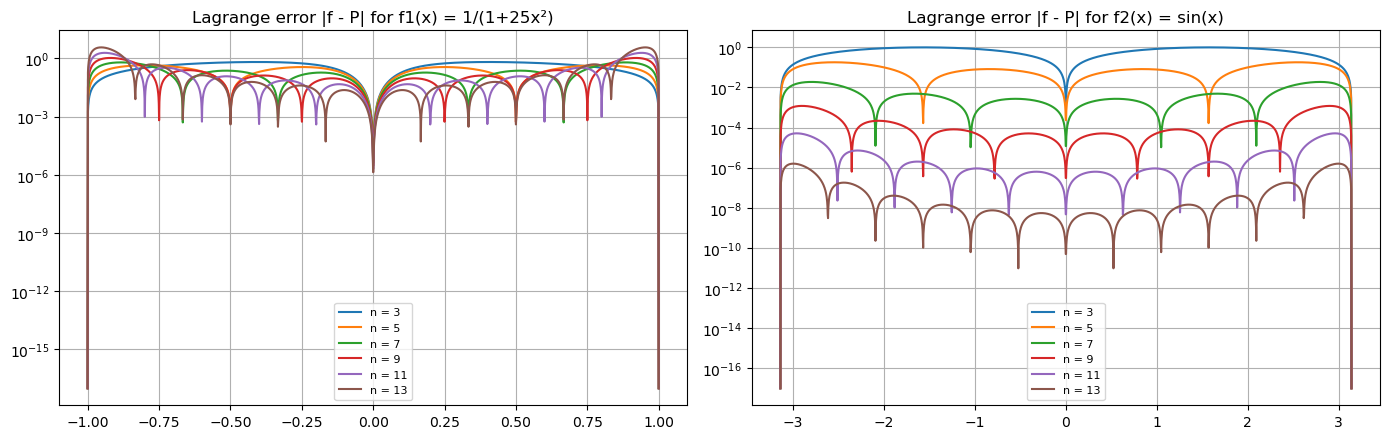

Lagrange : maximum error, equi nodes
   n           f1(x)           f2(x)
   3       6.462e-01       1.000e+00
   5       4.384e-01       1.808e-01
   7       6.169e-01       1.890e-02
   9       1.045e+00       1.206e-03
  11       1.916e+00       5.165e-05
  13       3.663e+00       1.589e-06
  15       7.195e+00       3.680e-08
  21       5.982e+01       1.502e-12


In [6]:
def plot_error(method, title, nodes=equi, ns=(3, 5, 7, 9, 11, 13)):
    # |f - P| (log scale), one axes per function
    fig, axes = plt.subplots(1, len(cases), figsize=(7*len(cases), 4.5))
    for ax, (name, (f, df, a, b)) in zip(axes, cases.items()):
        xs = np.linspace(a, b, 2000)
        for n in ns:
            X = nodes(a, b, n)
            err = np.abs(f(xs) - method(xs, X, f, df)) 
            ax.semilogy(xs, err + 1e-17, label=f"n = {n}")
        ax.set_title(f"{title} error |f - P| for {name}")
        ax.grid(True); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def error_table(method, title, nodes=equi, ns=(3, 5, 7, 9, 11, 13, 15, 21)):
    print(f"{title} : maximum error, {nodes.__name__} nodes")
    print(f"{'n':>4}" + "".join(f"{name.split(' =')[0]:>16}" for name in cases))
    for n in ns:
        row = f"{n:>4}"
        for name, (f, df, a, b) in cases.items():
            xs = np.linspace(a, b, 4000)
            X = nodes(a, b, n)
            row += f"{np.max(np.abs(f(xs) - method(xs, X, f, df))):>16.3e}"
        print(row)

plot_error(lagrange_eval, "Lagrange")
error_table(lagrange_eval, "Lagrange")

## Newton

In [7]:
def div_diff(x, y):
    f = list(y)

    for j in range(1, len(x)):
        for i in range(len(x) - 1, j - 1, -1):
            f[i] = (f[i] - f[i - 1]) / (x[i] - x[i - j])

    return f


def Newton(x, f, t):
    result = f[0]
    product = 1

    for i in range(1, len(f)):
        product *= (t - x[i - 1])
        result += f[i] * product

    return result

### Test

In [8]:
n = 5
polyN = {}

for name, (f, df, a, b) in cases.items():
    X = list(equi(a, b, n))
    Y = [f(i) for i in X]

    F = div_diff(X, Y)

    t0 = (a + b) / 4
    val = Newton(X, F, t0)
    print(name)
    print("   the value is : ", val, "   f(t0) =", f(t0), "   error =", abs(val - f(t0)))

    polyN[name] = sp.expand(Newton(X, F, x))
    print("   the polynome of Newton is :", clean(polyN[name]))
    print("   same as Lagrange ?  max coefficient difference =",
          max(abs(c) for c in sp.Poly(polyN[name] - polyL[name], x).all_coeffs()))
    print()

polyN

f1(x) = 1/(1+25x²)
   the value is :  1.0    f(t0) = 1.0    error = 0.0
   the polynome of Newton is : 3.3156*x**4 - 4.2772*x**2 + 1.0
   same as Lagrange ?  max coefficient difference = 9.5756735873919752e-16

f2(x) = sin(x)
   the value is :  -2.220446049250313e-16    f(t0) = 0.0    error = 2.220446049250313e-16
   the polynome of Newton is : -0.086*x**3 + 0.8488*x
   same as Lagrange ?  max coefficient difference = 2.2204460492503131e-16



{'f1(x) = 1/(1+25x²)': 3.315649867374*x**4 - 4.27718832891247*x**2 + 1.11022302462516e-16*x + 1.0,
 'f2(x) = sin(x)': -0.0860040918218653*x**3 + 0.848826363156775*x - 2.22044604925031e-16}

### Plot Newton polynomial

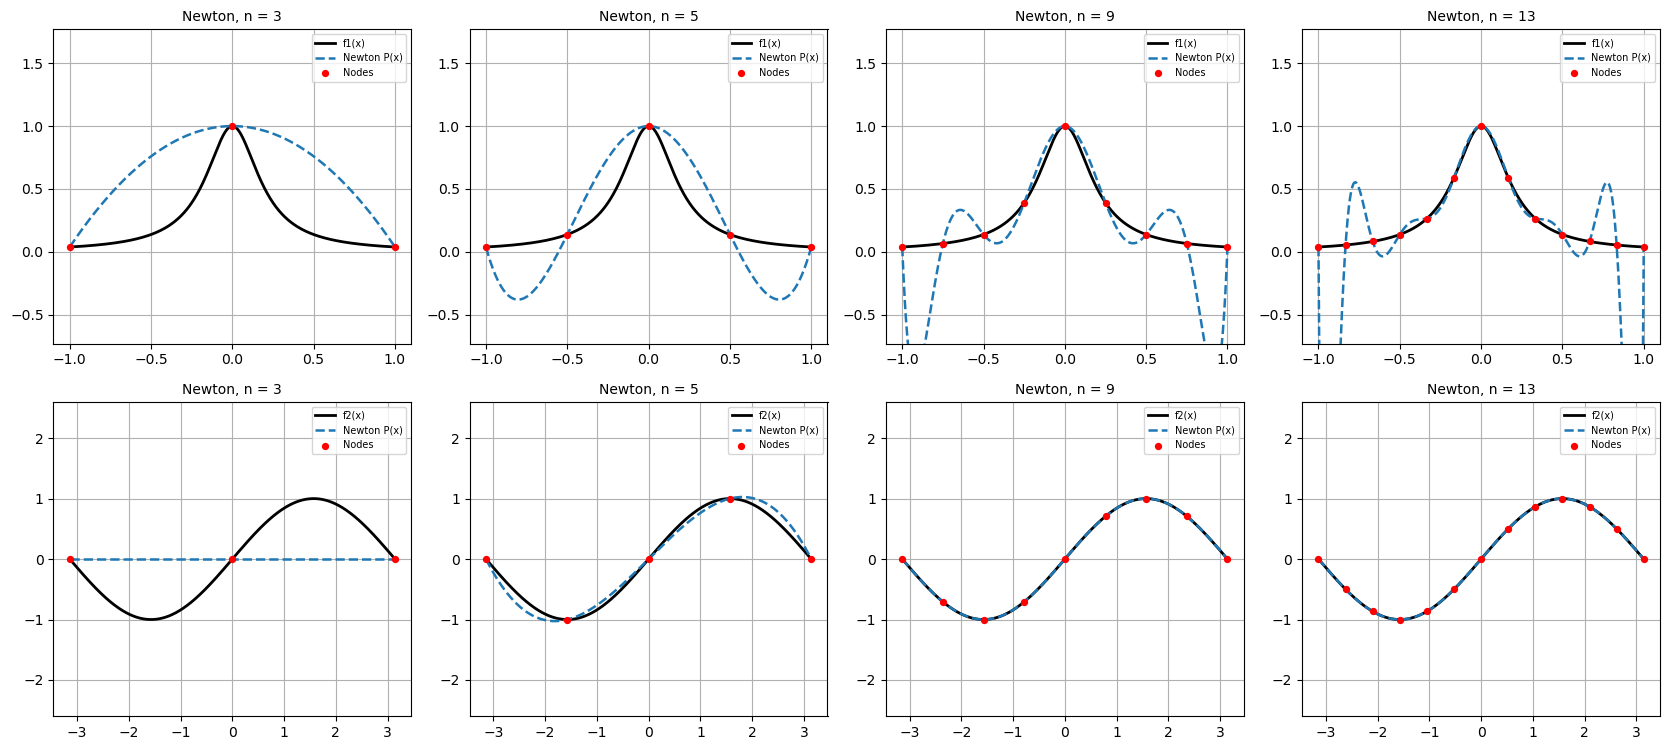

In [9]:
def newton_eval(xs, X, f, df):
    X = list(X)
    return Newton(X, div_diff(X, list(f(np.array(X)))), xs)

plot_method(newton_eval, "Newton")

### Visualise the error

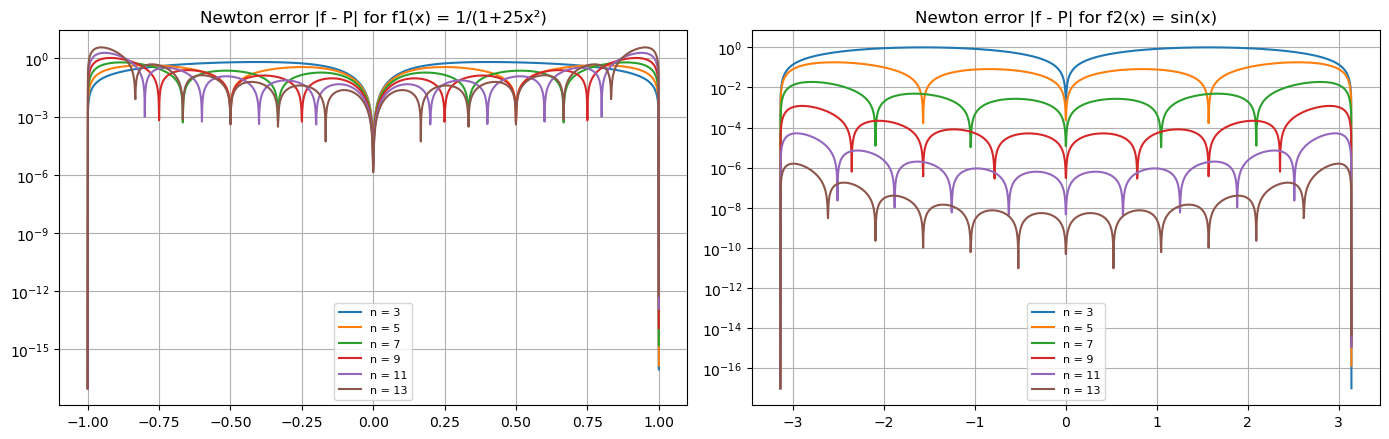

Newton : maximum error, equi nodes
   n           f1(x)           f2(x)
   3       6.462e-01       1.000e+00
   5       4.384e-01       1.808e-01
   7       6.169e-01       1.890e-02
   9       1.045e+00       1.206e-03
  11       1.916e+00       5.165e-05
  13       3.663e+00       1.589e-06
  15       7.195e+00       3.680e-08
  21       5.982e+01       1.352e-13


In [10]:
plot_error(newton_eval, "Newton")
error_table(newton_eval, "Newton")

## Hermite

Hermite uses the values **and** the derivatives at each node. Each node is repeated twice, and the derivative is used where the two nodes are equal.

In [11]:
def hermite_div_diff(X, Y, dY):
    Z, F = [], []
    for i in range(len(X)):
        Z += [X[i], X[i]]         
        F += [Y[i], Y[i]]

    for j in range(1, len(Z)):
        for i in range(len(Z) - 1, j - 1, -1):
            if Z[i] == Z[i - j]:
                F[i] = dY[i // 2]
            else:
                F[i] = (F[i] - F[i - 1]) / (Z[i] - Z[i - j])
    return Z, F

### Test

In [12]:
n = 3                                  
polyH = {}

for name, (f, df, a, b) in cases.items():
    X  = list(equi(a, b, n))
    Y  = [f(i) for i in X]
    dY = [df(i) for i in X]

    Z, H = hermite_div_diff(X, Y, dY)

    t0 = (a + b) / 4
    val = Newton(Z, H, t0)
    print(name)
    print("   the value is : ", val, "   f(t0) =", f(t0), "   error =", abs(val - f(t0)))

    polyH[name] = sp.expand(Newton(Z, H, x))
    print("   the polynome of Hermite is :", clean(polyH[name]))
    # check: P = f and P' = f' at the nodes
    print("   max |P - f| at nodes  =", max(abs(float(polyH[name].subs(x, t) - f(t))) for t in X))
    print("   max |P' - f'| at nodes =", max(abs(float(sp.diff(polyH[name], x).subs(x, t) - df(t))) for t in X))
    print()

polyH

f1(x) = 1/(1+25x²)
   the value is :  1.0    f(t0) = 1.0    error = 0.0
   the polynome of Hermite is : 0.9246*x**4 - 1.8861*x**2 + 1.0
   max |P - f| at nodes  = 1.3877787807814457e-16
   max |P' - f'| at nodes = 4.163336342344337e-17

f2(x) = sin(x)
   the value is :  0.0    f(t0) = 0.0    error = 0.0
   the polynome of Hermite is : 0.0051*x**5 - 0.152*x**3 + 1.0*x
   max |P - f| at nodes  = 7.657137397853899e-16
   max |P' - f'| at nodes = 8.881784197001252e-16



{'f1(x) = 1/(1+25x²)': 0.924556213017751*x**4 - 1.88609467455621*x**2 + 1.0,
 'f2(x) = sin(x)': 0.00513299112734217*x**5 + 3.46944695195361e-18*x**4 - 0.151981775463507*x**3 + 2.77555756156289e-17*x**2 + 1.0*x}

### Plot Hermite polynomial and error

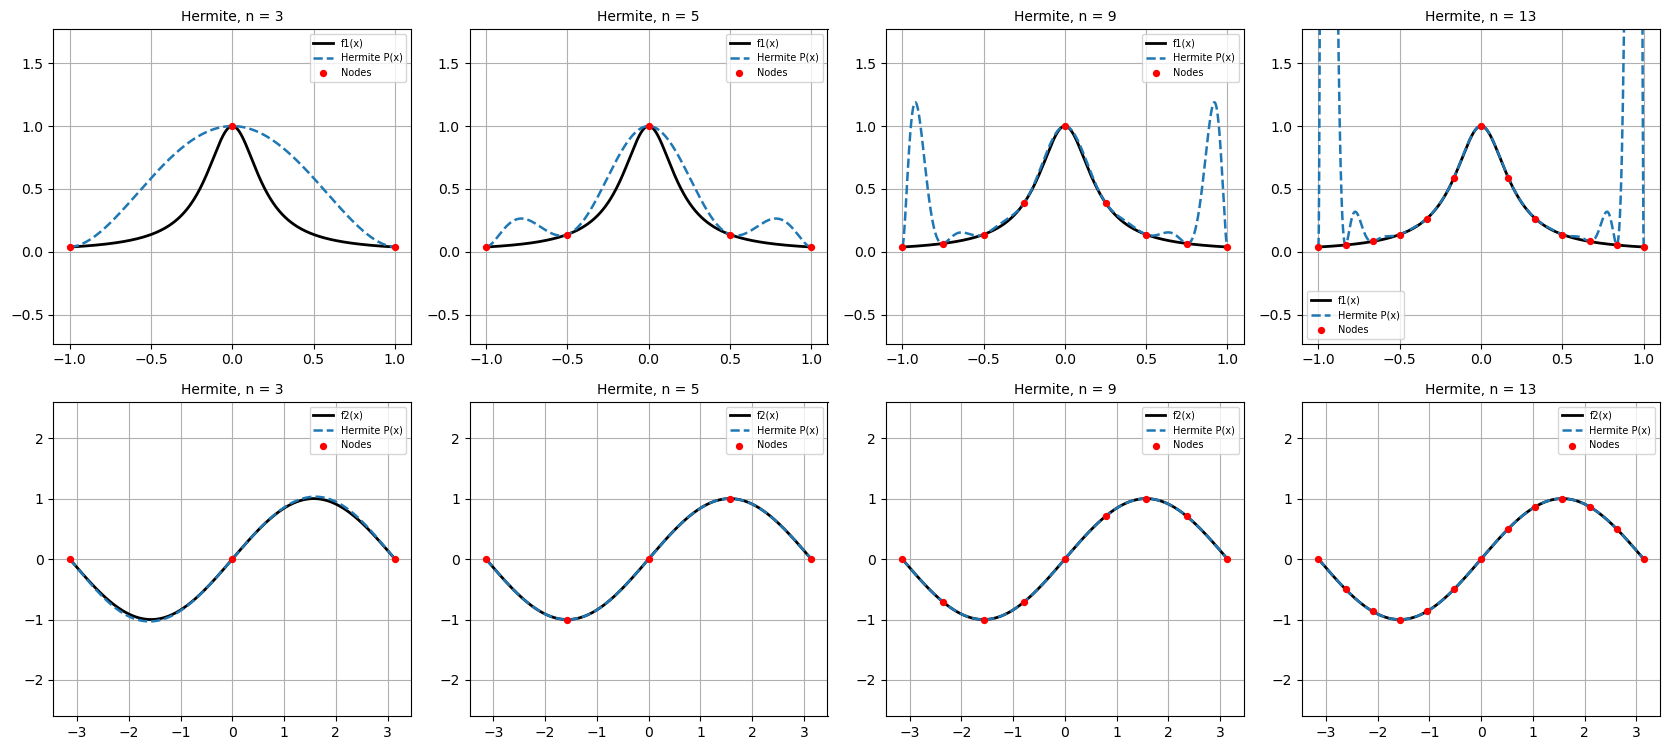

In [14]:
def hermite_eval(xs, X, f, df):
    X = list(X)
    Z, H = hermite_div_diff(X, list(f(np.array(X))), list(df(np.array(X))))
    return Newton(Z, H, xs)

plot_method(hermite_eval, "Hermite")

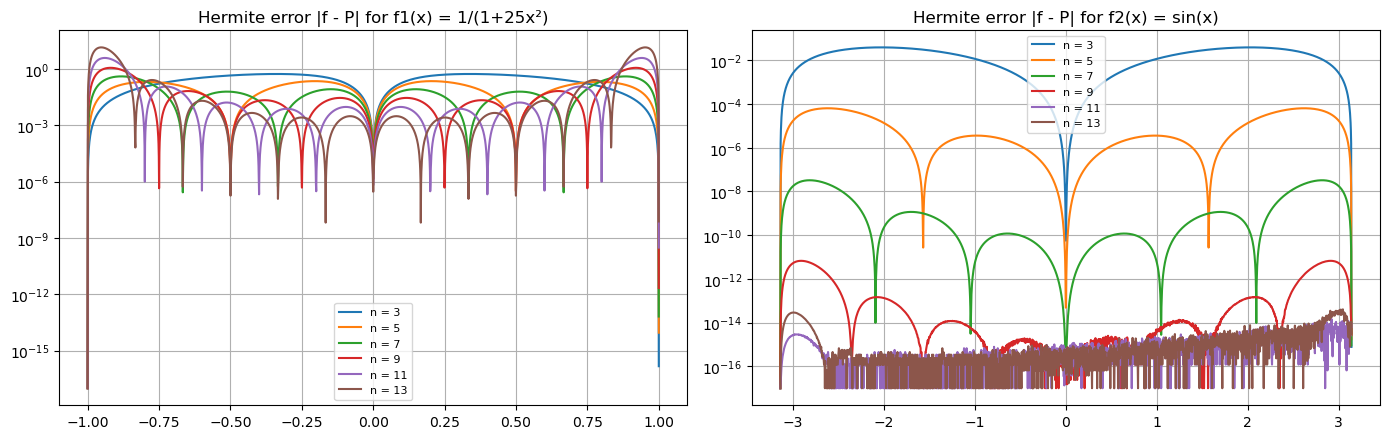

Hermite : maximum error, equi nodes
   n           f1(x)           f2(x)
   3       5.373e-01       3.915e-02
   5       2.236e-01       6.418e-05
   7       4.002e-01       3.267e-08
   9       1.144e+00       6.745e-12
  11       3.836e+00       1.850e-14
  13       1.401e+01       4.176e-14
  15       5.401e+01       8.554e-14
  21       3.729e+03       2.540e-09


In [15]:
plot_error(hermite_eval, "Hermite")
error_table(hermite_eval, "Hermite")

## La phenomenon of RUNGE

**Runge phenomenon.** When a function f is interpolated by a polynomial of high degree on **equally spaced nodes**, the polynomial can oscillate strongly near the ends of the interval. In that case, increasing the number of nodes n does **not** reduce the error: the maximum error grows with n and the polynomial does not converge to f. This was discovered by Carl Runge in 1901 with the function f(x) = 1 / (1 + 25x²) on [-1, 1].

It comes from the error formula f(x) - P(x) = f⁽ⁿ⁾(ξ)/n! · Π(x - xᵢ): for this kind of function the derivatives grow very fast, and with equally spaced nodes the product Π|x - xᵢ| is much larger near the ends than in the middle.

It can be avoided by using Chebyshev nodes (more concentrated near the ends) or piecewise polynomials (splines).

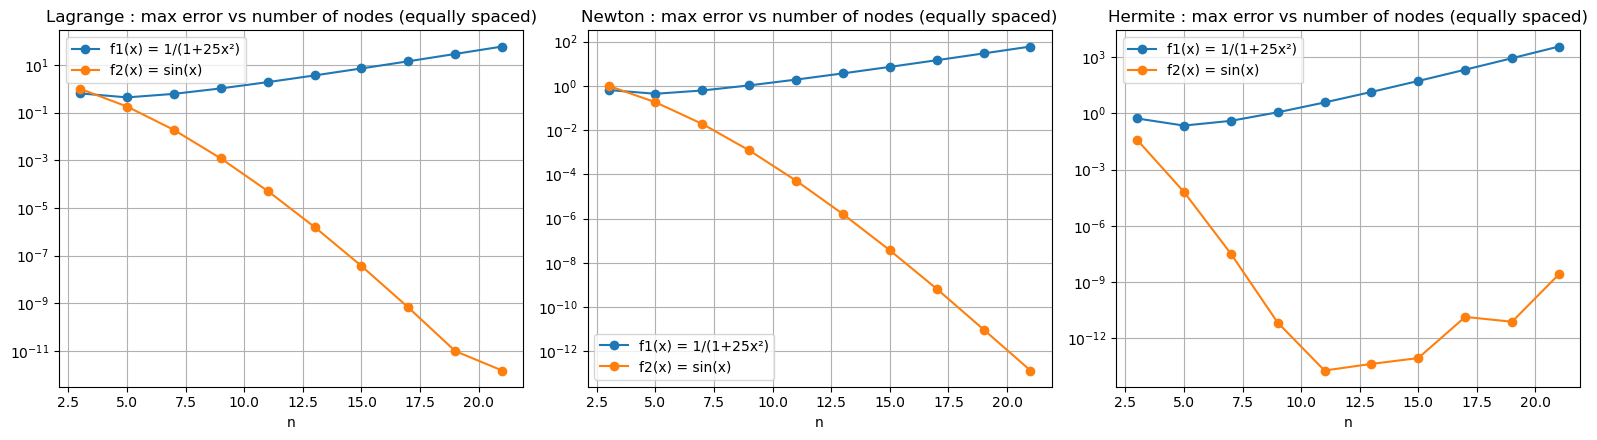

In [16]:
methods = {"Lagrange": lagrange_eval, "Newton": newton_eval, "Hermite": hermite_eval}
ns_run = list(range(3, 22, 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title, method) in zip(axes, methods.items()):
    for name, (f, df, a, b) in cases.items():
        xs = np.linspace(a, b, 4000)
        errs = [np.max(np.abs(f(xs) - method(xs, equi(a, b, n), f, df))) for n in ns_run]
        ax.semilogy(ns_run, errs, "o-", label=name)
    ax.set_title(f"{title} : max error vs number of nodes (equally spaced)")
    ax.set_xlabel("n"); ax.grid(True); ax.legend()
plt.tight_layout()
plt.show()

For f₁, the error **grows** with n (Runge phenomenon). For f₂ = sin(x) it decreases very fast to 0 (until rounding errors for Hermite with a very high degree).

The error formula explains it: f(x) - P(x) = f⁽ⁿ⁾(ξ)/n! · Π(x - xᵢ). For f₂ the derivatives are bounded by 1, so the error goes to 0. For f₁ the derivatives grow very quickly, and with equally spaced nodes the product Π|x - xᵢ| is much bigger near the ends of the interval.

## Conclusion

- **Lagrange** and **Newton** give exactly the same polynomial, because the interpolation polynomial through the same points is unique (checked above: the coefficients are identical). Newton is more efficient, because the divided differences are computed once and a new point only adds one term.
- **Hermite** is more accurate near the nodes since it also matches the derivatives (the curve is tangent to f at each node), but it has a higher degree (2n - 1) and needs f'.
- For **f₂ = sin(x)**, increasing the number of nodes improves the approximation quickly and steadily.
- For **f₁ = 1/(1+25x²)** with equally spaced nodes, the **Runge phenomenon** appears: using more nodes does not improve the result, the polynomial oscillates strongly near the ends of the interval and the maximum error grows with n (Hermite, with its higher degree, is even worse).
- To avoid it, we can use **Chebyshev nodes** (the error then decreases when n increases) or **piecewise interpolation (splines)** instead of a single high-degree polynomial.

In [ ]:
## THE END